## 绘制关于”在不同exploration 迭代数量的情况下，在特定攻击实验中我们的方法性能“相关的图

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

In [13]:
filename = "../data/results/DyTA_Llama3_res_harmBench_100_T2.0_S30_FRL30_NOI15_NII400_0_100.jsonl"

In [14]:
def load_jsonl(filename):
    data = []
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

In [15]:
all_data = load_jsonl(filename)
success_data = [d for d in all_data if d["best_unsafe_score"] >= 0.5]

In [16]:
print(len(all_data))
print(len(success_data))

100
68


In [17]:
M = 15 # the maximum number of iterations
iter_success_cnt = [0 for _ in range(M + 1)]
iter_total_cnt = len(success_data)

for d in success_data:
    iter_success_cnt[d["best_iter_idx"]] += 1

iter_cum_cnt = [0 for _ in range(M + 1)]
for i in range(1, M + 1):
    iter_cum_cnt[i] = iter_cum_cnt[i - 1] + iter_success_cnt[i]

# Calculate the success rate for each iteration
success_rate = [0 for _ in range(M + 1)]
for i in range(1, M + 1):
    success_rate[i] = round(iter_success_cnt[i] / iter_total_cnt, 4)

cum_success_rate = [round(iter_cum_cnt[i] / iter_total_cnt, 4) for i in range(M + 1)]

In [20]:
print(iter_success_cnt)

[0, 11, 8, 22, 7, 3, 2, 4, 1, 2, 2, 0, 0, 0, 5, 1]


In [18]:
print(success_rate)

[0, 0.1618, 0.1176, 0.3235, 0.1029, 0.0441, 0.0294, 0.0588, 0.0147, 0.0294, 0.0294, 0.0, 0.0, 0.0, 0.0735, 0.0147]


In [19]:
print(cum_success_rate)

[0.0, 0.1618, 0.2794, 0.6029, 0.7059, 0.75, 0.7794, 0.8382, 0.8529, 0.8824, 0.9118, 0.9118, 0.9118, 0.9118, 0.9853, 1.0]


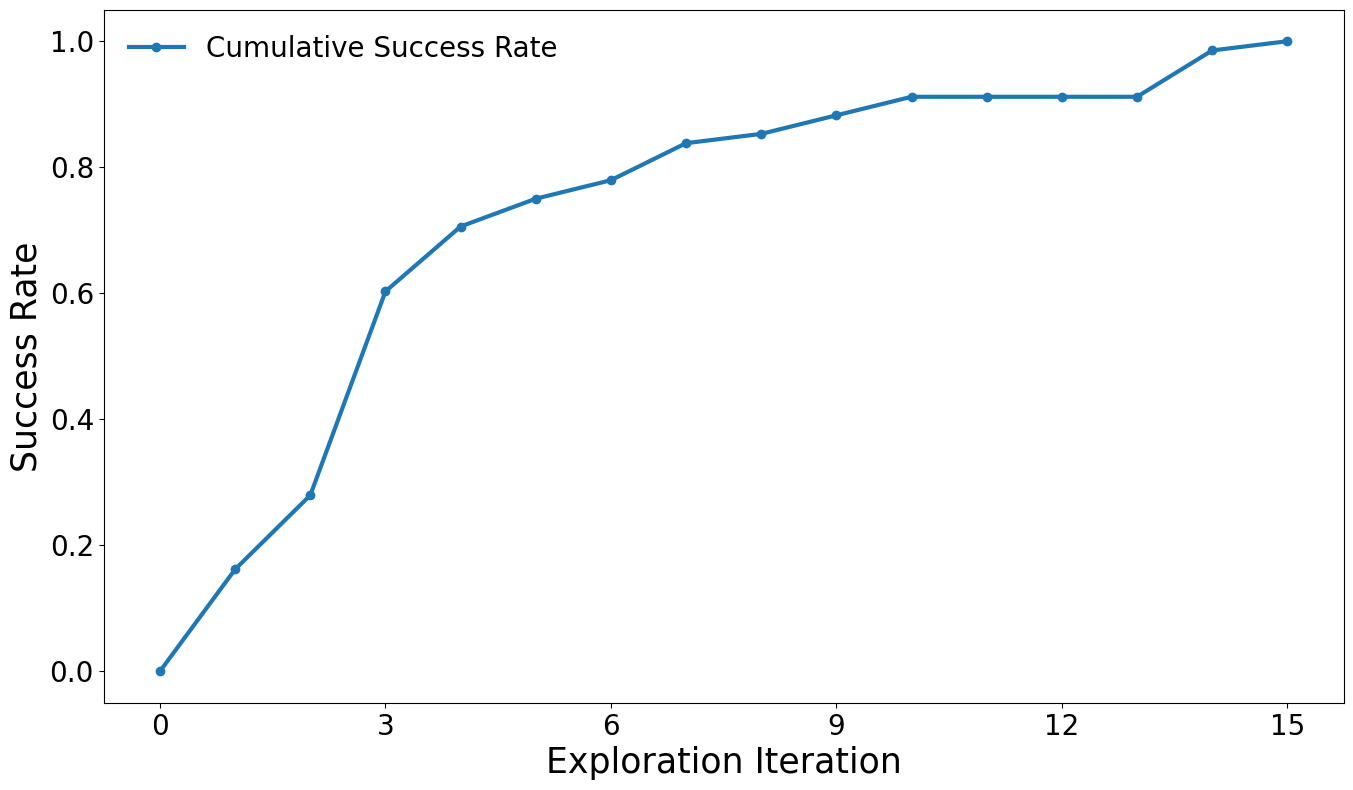

In [37]:
# Plotting the success rate
plt.figure(figsize=(16, 9))
# plt.plot(range(M + 1), success_rate, marker='o', label='Success Rate')
plt.plot(range(M + 1), cum_success_rate, marker='o', label='Cumulative Success Rate', linewidth = 3)
# plt.title('Success Rate vs Iteration')
plt.xlabel(r'Exploration Iteration', fontsize = 25)
plt.ylabel("Success Rate", fontsize=25)
plt.xticks(list(range(0, M + 1, 3)), fontsize = 20)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=20)
# plt.grid()
plt.legend(frameon = False, fontsize=20)
# plt.savefig("success_rate.png", dpi=300)
plt.savefig("./figs/sucess_vs_iter.pdf", dpi=1200, bbox_inches="tight")
plt.show()